# Evaluasi Struktur Biaya, Subsidi Pengiriman, dan Risiko Pembatalan pada Transaksi E-Commerce Indonesia

## Latar Belakang dan Tujuan Analisis
Proyek ini bertujuan untuk:
- Mengevaluasi struktur biaya pengiriman dan efisiensi logistik
- Menilai efektivitas subsidi pengiriman terhadap risiko operasional
- Mengidentifikasi faktor-faktor yang berkontribusi terhadap pembatalan pesanan
- Menentukan area atau segmen yang menunjukkan indikasi inefisiensi operasional

Analisis difokuskan pada segmentasi berdasarkan:
- Provinsi
- Metode pembayaran
- Kategori produk

Karena sebagian besar data tidak memiliki informasi waktu yang lengkap, analisis tidak difokuskan pada tren waktu, melainkan pada evaluasi struktural dan segmentasi operasional.

**Output :** Hasil analisis diharapkan dapat memberikan rekomendasi terkait optimalisasi subsidi, pengendalian biaya logistik, dan prioritas perbaikan operasional berdasarkan segmentasi wilayah dan metode pembayaran.

In [1]:
#Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [2]:
# Setting tampilan
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

# Setting gaya visual
sns.set_theme(style="whitegrid")

____
## 1. Data Understanding
Pada bagian ini yang dilakukan meliputi:
- Load dataset
- Cek struktur kolom, tipe data, missing values, dan ringkasan statistik awal



### Load Dataset

In [3]:

url = "https://raw.githubusercontent.com/AlvitoDwiP/operasional_ecommers_indo/refs/heads/main/data/raw/all_months_clean.csv"
df = pd.read_csv(
    url,
    sep=";",               
    encoding="utf-8-sig",  
    engine="python"
)

print("Shape:", df.shape)
df.head()


Shape: (20848, 19)


,order_id,total_qty,total_weight_gr,total_returned_qty,Total Diskon,product_categories,num_product_categories,Status Pesanan,Alasan Pembatalan,Opsi Pengiriman,Metode Pembayaran,Kota/Kabupaten,Provinsi,Ongkos Kirim Dibayar oleh Pembeli,Estimasi Potongan Biaya Pengiriman,Total Pembayaran,Perkiraan Ongkos Kirim,Waktu Pesanan Dibuat,source_file
0,ORD_0000001,2,2000,0,0,Celengan,1,Selesai,NaN,Reguler (Cashless)-SPX Standard,Saldo ShopeePay,KOTA SERANG,BANTEN,0,10000,38300,10000,2024-04-01 00:15,AprilSales2024.xlsx
1,ORD_0000002,1,500,0,0,Celengan,1,Selesai,NaN,Hemat Kargo-SPX Hemat,COD (Bayar di Tempat),KOTA SEMARANG,JAWA TENGAH,0,14500,18576,14500,2024-04-01 01:47,AprilSales2024.xlsx
2,ORD_0000003,1,500,0,0,Celengan,1,Selesai,NaN,Hemat Kargo-SPX Hemat,SeaBank Bayar Instan,KAB. BOGOR,JAWA BARAT,0,8000,7069,8000,2024-04-01 04:25,AprilSales2024.xlsx
3,ORD_0000004,2,400,0,0,Mangkok Sambal / Saus,1,Selesai,NaN,Hemat Kargo-SPX Hemat,COD (Bayar di Tempat),KOTA JAMBI,JAMBI,0,20000,32200,20000,2024-04-01 04:41,AprilSales2024.xlsx
4,ORD_0000005,3,3600,0,0,"Keranjang, Other, Tempat Nasi",3,Batal,Dibatalkan oleh Pembeli. Alasan: Ubah Pesanan ...,Hemat Kargo-SPX Hemat,COD (Bayar di Tempat),KOTA TANGERANG,BANTEN,0,0,0,8000,2024-04-01 06:12,AprilSales2024.xlsx


Insight:

Dataset terdiri dari sejumlah transaksi tingkat pesanan (order-level), setiap baris merepresentasikan satu pesanan, dataset siap untuk proses eksplorasi struktur dan kualitas data.

### Cek struktur kolom, tipe data, missing values, dan ringkasan statistik awal

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20848 entries, 0 to 20847
Data columns (total 19 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   order_id                            20848 non-null  object
 1   total_qty                           20848 non-null  int64 
 2   total_weight_gr                     20848 non-null  int64 
 3   total_returned_qty                  20848 non-null  int64 
 4   Total Diskon                        20848 non-null  int64 
 5   product_categories                  20848 non-null  object
 6   num_product_categories              20848 non-null  int64 
 7   Status Pesanan                      20848 non-null  object
 8   Alasan Pembatalan                   2830 non-null   object
 9   Opsi Pengiriman                     20848 non-null  object
 10  Metode Pembayaran                   20848 non-null  object
 11  Kota/Kabupaten                      20848 non-null  ob

**Interpretasi:**
dataset berisi 20.848 baris dengan mayoritas kolom sudah lengkap dan tipe numerik utama sudah benar, namun Alasan Pembatalan sangat banyak kosong (wajar jika hanya untuk order batal) serta Waktu Pesanan Dibuat masih bertipe teks dan sebagian null sehingga perlu dibersihkan dulu sebelum analisis waktu.

#### **Cek Missing values**

In [5]:
missing = df.isna().sum().sort_values(ascending=False).to_frame("Missing Count")
missing["Missing (%)"] = (missing["Missing Count"] / len(df) * 100).round(2)
missing.head(10)


,Missing Count,Missing (%)
Alasan Pembatalan,18018,86.43
Waktu Pesanan Dibuat,1980,9.50
order_id,0,0.00
total_weight_gr,0,0.00
total_qty,0,0.00
product_categories,0,0.00
total_returned_qty,0,0.00
num_product_categories,0,0.00
Status Pesanan,0,0.00
Opsi Pengiriman,0,0.00


**Interpretasi:**
- Waktu Pesanan Dibuat missing besar → tren bulanan tidak dipakai.
- Analisis difokuskan pada evaluasi struktural dan segmentasi operasional, bukan tren waktu.

#### **Statistik deskriptif numerik**

In [6]:
df.describe(include="number").T


,count,mean,std,min,25%,50%,75%,max
total_qty,20848.0,2.560821,7.796763,1.0,1.0,1.0,2.0,256.0
total_weight_gr,20848.0,2004.529691,7106.357515,10.0,300.0,500.0,1600.0,375000.0
total_returned_qty,20848.0,0.017748,0.548656,0.0,0.0,0.0,0.0,70.0
Total Diskon,20848.0,405.199348,9784.017705,0.0,0.0,0.0,0.0,700000.0
num_product_categories,20848.0,1.112097,0.485361,1.0,1.0,1.0,1.0,11.0
Ongkos Kirim Dibayar oleh Pembeli,20848.0,4189.990695,13578.489678,0.0,0.0,0.0,3000.0,584000.0
Estimasi Potongan Biaya Pengiriman,20848.0,10722.539284,12672.471066,0.0,0.0,9500.0,15000.0,312000.0
Total Pembayaran,20848.0,50683.597036,144019.263221,0.0,13480.0,21800.0,41600.0,3403591.0
Perkiraan Ongkos Kirim,20848.0,18425.626343,23791.508665,1.0,8000.0,11000.0,20000.0,959200.0


- Untuk “sanity check”: tidak boleh ada ongkir negatif, berat negatif, qty negatif.
- Jika max terlalu ekstrem → nanti kita handle outlier (bukan dihapus langsung, tapi di-clip/winsorize untuk visualisasi).



### Gambaran Operasional Cepat (Grafik kuat)
Bagian ini bertujuan untuk memahami kondisi operasional secara umum sebelum masuk ke analisis biaya dan subsidi.
Kita akan melihat:
- Distribusi status pesanan
- Tingkat pembatalan keseluruhan
- Wilayah dengan volume transaksi terbesar

#### A) Distribusi status pesanan

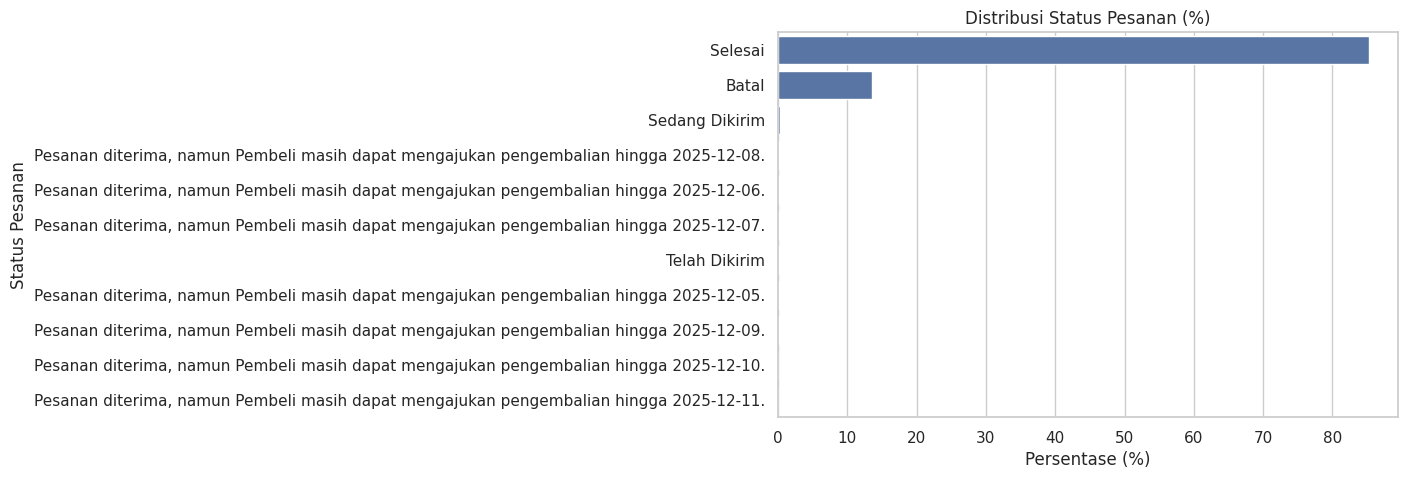

In [7]:
status_dist = df["Status Pesanan"].value_counts(normalize=True) * 100

plt.figure(figsize=(8,5))
sns.barplot(x=status_dist.values, y=status_dist.index)
plt.title("Distribusi Status Pesanan (%)")
plt.xlabel("Persentase (%)")
plt.ylabel("Status Pesanan")
plt.show()



**Insight**
Grafik ini menunjukkan bagaimana kondisi akhir setiap pesanan dalam sistem.
Beberapa poin penting yang bisa diperhatikan:
- Status “Selesai” biasanya menjadi proporsi terbesar, yang menunjukkan sebagian besar transaksi berhasil diproses hingga akhir.
- Status “Batal” menjadi indikator risiko operasional. Semakin besar proporsinya, semakin besar potensi inefisiensi dalam proses transaksi.
- Status lain seperti “Sedang Dikirim” atau “Telah Dikirim” menunjukkan transaksi yang masih dalam proses atau telah mencapai tahap pengiriman.

Jika proporsi batal cukup signifikan, maka analisis lebih lanjut terhadap faktor biaya dan metode pembayaran menjadi sangat relevan.

#### B) Tingkat Pembatalan Keseluruhan

In [8]:
df["cancel_flag"] = np.where(
    df["Status Pesanan"].str.lower() == "batal", 1, 0
)

cancel_rate = df["cancel_flag"].mean() * 100
print(f"Cancellation Rate: {cancel_rate:.2f}%")


Cancellation Rate: 13.57%


**Insight**
Cancellation rate menunjukkan persentase pesanan yang dibatalkan dari seluruh transaksi.

Secara sederhana jika cancellation rate = 13%, berarti dari setiap 100 pesanan, sekitar 13 pesanan dibatalkan.

Ini penting karena:
- Setiap pembatalan berpotensi menyebabkan biaya logistik terbuang.
- Jika subsidi sudah diberikan sebelum pesanan dibatalkan, maka perusahaan tetap menanggung biaya tersebut.

Tingkat pembatalan yang tinggi bisa mengindikasikan masalah seperti:
- Ongkos kirim terlalu mahal
- Metode pembayaran kurang terpercaya
- Masalah stok atau pengiriman


Nilai ini akan menjadi pembanding ketika kita melihat cancellation rate per provinsi dan metode pembayaran.

#### C) Top 10 Provinsi Berdasarkan Jumlah Order

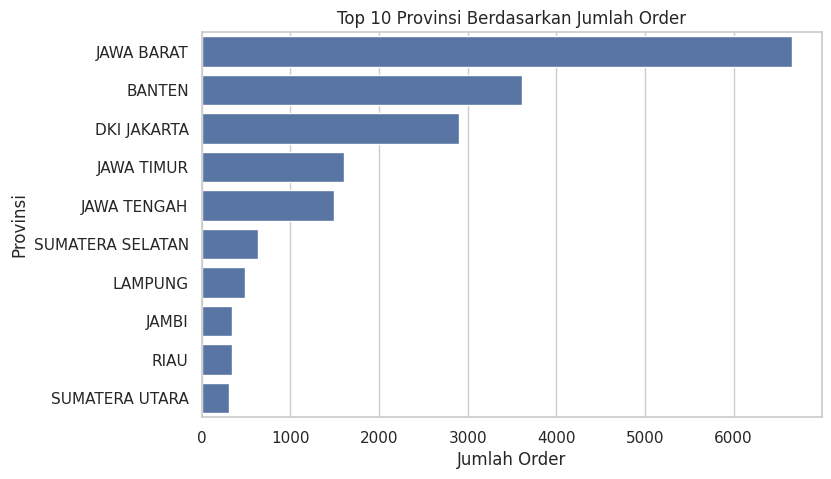

In [9]:
top_province = (
    df["Provinsi"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(8,5))
sns.barplot(x=top_province.values, y=top_province.index)
plt.title("Top 10 Provinsi Berdasarkan Jumlah Order")
plt.xlabel("Jumlah Order")
plt.show()


**Insight**

Grafik ini menunjukkan provinsi mana yang memiliki transaksi terbesar.

Beberapa interpretasi penting:
- Provinsi dengan volume tinggi memberikan kontribusi besar terhadap total pendapatan dan total biaya logistik.
- Jika provinsi dengan volume tinggi memiliki cancellation rate tinggi, maka dampaknya terhadap efisiensi operasional akan jauh lebih besar dibanding provinsi kecil.
- Wilayah dominan ini akan menjadi fokus utama dalam evaluasi subsidi dan struktur biaya.

#### D) Distribusi Metode Pembayaran

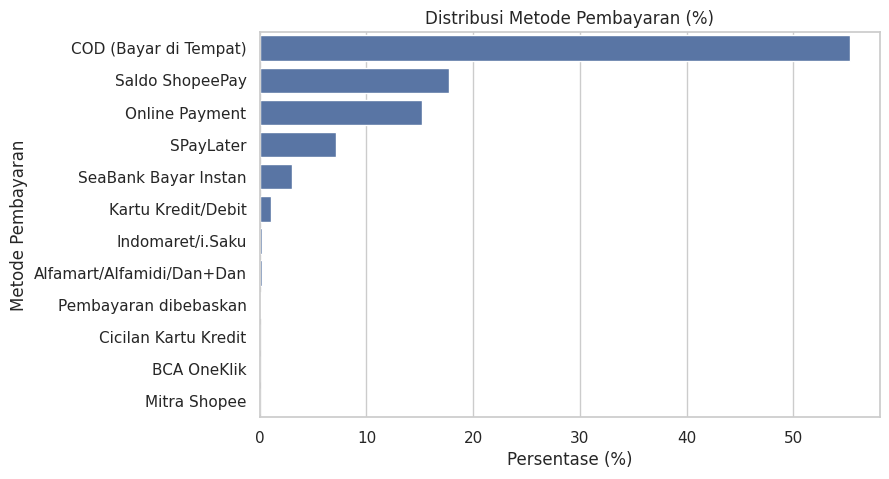

In [10]:
payment_dist = df["Metode Pembayaran"].value_counts(normalize=True) * 100

plt.figure(figsize=(8,5))
sns.barplot(x=payment_dist.values, y=payment_dist.index)
plt.title("Distribusi Metode Pembayaran (%)")
plt.xlabel("Persentase (%)")
plt.ylabel("Metode Pembayaran")
plt.show()


**Insight**

Distribusi metode pembayaran menunjukkan preferensi pelanggan dalam menyelesaikan transaksi.

Beberapa hal yang bisa diamati:
- Metode pembayaran dominan kemungkinan memiliki tingkat kepercayaan lebih tinggi.
- Metode pembayaran tertentu seringkali memiliki risiko pembatalan lebih besar (misalnya metode bayar di tempat / COD, jika tersedia).
- Jika satu metode mendominasi dan memiliki cancellation rate tinggi, maka itu menjadi prioritas evaluasi.

### INSIGHT GAMBARAN OPERASIONAL 
Dari gambaran operasional awal ini, kita sudah mengetahui:
- Seberapa besar tingkat pembatalan secara umum
- Wilayah mana yang paling berkontribusi terhadap volume transaksi
- Metode pembayaran dominan dalam sistem

Bagian ini memberikan konteks penting sebelum masuk ke analisis inti, yaitu:
- Apakah ongkos kirim terlalu tinggi?
- Apakah subsidi sudah tepat sasaran?
- Apakah ada hubungan antara biaya logistik dan pembatalan pesanan?

----

## 2. Data Preprocessing & Feature Engineering
Setelah memahami struktur dan kualitas data, tahap berikutnya adalah menyiapkan dataset agar siap digunakan untuk analisis biaya, subsidi, dan risiko pembatalan.

Pada tahap ini dilakukan:
- Menghapus kolom yang tidak memiliki nilai analitis (misalnya kolom teknis sumber file)
- Menstandarkan nama kolom agar konsisten dan mudah digunakan dalam analisis
- Membuat indikator pembatalan (cancel_flag) untuk mengukur risiko transaksi
- Mengonversi berat dari gram ke kilogram agar sesuai dengan praktik perhitungan logistik
- Menghitung ongkir per kilogram sebagai indikator efisiensi biaya distribusi
- Mengidentifikasi transaksi free shipping untuk memisahkan analisis subsidi dan biaya aktual
- Membuat dataset khusus transaksi dengan ongkir dibayar agar analisis efisiensi logistik tidak bias
- Menangani outlier ekstrem (melalui clipping persentil ke-99) untuk menjaga kestabilan visualisasi

Tujuan utama preprocessing pada proyek ini adalah memastikan bahwa metrik yang digunakan benar-benar mencerminkan kondisi operasional yang nyata, sehingga analisis selanjutnya dapat dilakukan secara objektif dan tidak bias.

### Menghapus Kolom yang Tidak Relevan
Kolom source_file hanya menunjukkan asal file dan tidak memiliki nilai analitis dalam konteks bisnis.

In [11]:
df = df.drop(columns=["source_file"], errors="ignore")

df.columns


Index(['order_id', 'total_qty', 'total_weight_gr', 'total_returned_qty', 'Total Diskon', 'product_categories', 'num_product_categories', 'Status Pesanan', 'Alasan Pembatalan', 'Opsi Pengiriman',
       'Metode Pembayaran', 'Kota/Kabupaten', 'Provinsi', 'Ongkos Kirim Dibayar oleh Pembeli', 'Estimasi Potongan Biaya Pengiriman', 'Total Pembayaran', 'Perkiraan Ongkos Kirim',
       'Waktu Pesanan Dibuat', 'cancel_flag'],
      dtype='object')

### Standarisasi Nama Kolom
Agar penulisan kode lebih rapi dan konsisten, beberapa kolom dengan spasi dan huruf kapital akan disederhanakan.

In [12]:
rename_map = {
    "Total Diskon": "total_diskon",
    "Status Pesanan": "status_pesanan",
    "Alasan Pembatalan": "alasan_pembatalan",
    "Opsi Pengiriman": "opsi_pengiriman",
    "Metode Pembayaran": "metode_pembayaran",
    "Kota/Kabupaten": "kota_kabupaten",
    "Provinsi": "provinsi",
    "Ongkos Kirim Dibayar oleh Pembeli": "ongkir_dibayar",
    "Estimasi Potongan Biaya Pengiriman": "subsidi_ongkir",
    "Total Pembayaran": "total_pembayaran",
    "Perkiraan Ongkos Kirim": "perkiraan_ongkir",
    "total_weight_gr": "total_berat_gr"
}

df = df.rename(columns=rename_map)
df.columns


Index(['order_id', 'total_qty', 'total_berat_gr', 'total_returned_qty', 'total_diskon', 'product_categories', 'num_product_categories', 'status_pesanan', 'alasan_pembatalan', 'opsi_pengiriman',
       'metode_pembayaran', 'kota_kabupaten', 'provinsi', 'ongkir_dibayar', 'subsidi_ongkir', 'total_pembayaran', 'perkiraan_ongkir', 'Waktu Pesanan Dibuat', 'cancel_flag'],
      dtype='object')

### Membuat Indikator Pembatalan (Cancellation Flag)
Untuk memudahkan perhitungan tingkat pembatalan pada berbagai segmen, dibuat variabel biner:
- 1 = Batal
- 0 = Tidak batal

In [13]:
df["cancel_flag"] = np.where(
    df["status_pesanan"].str.lower() == "batal",
    1,
    0
)

df["cancel_flag"].mean()


np.float64(0.13574443591711435)

**Interpretasi**
- Nilai rata-rata cancel_flag menunjukkan tingkat pembatalan keseluruhan.
- Variabel ini akan menjadi indikator risiko utama dalam analisis selanjutnya, terutama ketika dibandingkan antar provinsi dan metode pembayaran.

### Konversi Berat ke Kilogram
Karena berat masih dalam gram, kita konversi ke kilogram agar lebih mudah diinterpretasikan.

In [14]:
df["total_berat_kg"] = df["total_berat_gr"] / 1000

df[["total_berat_gr", "total_berat_kg"]].head()


,total_berat_gr,total_berat_kg
0,2000,2.0
1,500,0.5
2,500,0.5
3,400,0.4
4,3600,3.6


**Interpretasi**

Berat dalam kilogram lebih intuitif untuk analisis biaya logistik, terutama saat menghitung ongkir per kg.

### Menghitung Ongkir per Kilogram
Ongkir per kilogram digunakan sebagai indikator efisiensi biaya logistik.

In [15]:
df["ongkir_per_kg"] = np.where(
    df["total_berat_kg"] > 0,
    df["ongkir_dibayar"] / df["total_berat_kg"],
    np.nan
)

df["ongkir_per_kg"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])


,ongkir_per_kg
count,20848.000000
mean,6478.887448
std,24408.963300
min,0.000000
25%,0.000000
50%,0.000000
75%,1978.245028
90%,16000.000000
95%,35000.000000
99%,97500.000000


**Interpretasi**

- Sekitar 70% nilai ongkir per kg = 0
- Median = 0
- Distribusi sangat condong ke kanan (right-skewed)
- Nilai maksimum sangat tinggi (hingga ratusan ribu per kg)

Ini menandakan bahwa banyak transaksi tidak membayar ongkir secara langsung (free shipping), dan terdapat beberapa transaksi dengan berat sangat kecil yang menghasilkan nilai ongkir per kg ekstrem.

Karena itu, kita perlu memisahkan transaksi free shipping dari transaksi berbayar.

### Identifikasi Transaksi Free Shipping

In [16]:
df["free_shipping_flag"] = np.where(df["ongkir_dibayar"] == 0, 1, 0)

(df["free_shipping_flag"].mean() * 100)


np.float64(69.80046047582502)

Hasil kurang lebih 70%, artinya mayoritas transaksi tidak membayar ongkir secara langsung.

Hal ini penting secara bisnis karena:
- Ongkir mungkin disubsidi penuh oleh perusahaan
- Analisis efisiensi logistik tidak boleh mencampur transaksi gratis dan berbayar
- Evaluasi subsidi menjadi semakin relevan

### Membuat Dataset Khusus untuk Analisis Biaya Aktual
Untuk mengevaluasi efisiensi logistik secara objektif, kita hanya menggunakan transaksi dengan ongkir dibayar > 0.

In [17]:
df_paid = df[df["ongkir_dibayar"] > 0].copy()

df_paid["ongkir_per_kg"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])


,ongkir_per_kg
count,6296.000000
mean,21453.596809
std,40642.044674
min,0.227273
25%,3137.254902
50%,10000.000000
75%,22500.000000
90%,50000.000000
95%,80000.000000
99%,170093.750000


Dataset ini mencerminkan biaya logistik yang benar-benar dibayar pelanggan.

Dengan memisahkan transaksi berbayar, kita dapat:
- Mengukur distribusi biaya secara lebih realistis
- Membandingkan efisiensi antar wilayah
- Menghindari bias akibat free shipping

### Menangani Outlier untuk Keperluan Visualisasi
Nilai ekstrem (misalnya akibat berat sangat kecil) dapat merusak visualisasi sehingga perlu kita lakukan pembatasan pada persentil ke-99.

In [18]:
upper_cap = df_paid["ongkir_per_kg"].quantile(0.99)

df_paid["ongkir_per_kg_clipped"] = np.where(
    df_paid["ongkir_per_kg"] > upper_cap,
    upper_cap,
    df_paid["ongkir_per_kg"]
)

df_paid["ongkir_per_kg_clipped"].describe()


,ongkir_per_kg_clipped
count,6296.000000
mean,20114.545645
std,28917.210029
min,0.227273
25%,3137.254902
50%,10000.000000
75%,22500.000000
max,170093.750000


Clipping dilakukan hanya untuk tujuan visualisasi, bukan untuk mengubah data asli.

Dengan membatasi nilai ekstrem:
- Grafik menjadi lebih representatif
- Distribusi biaya lebih mudah dibaca
- Insight lebih stabil dan tidak dipengaruhi outlier kecil

****


ekspor dataset yang akan digunakan ke notebooks selanjutnya

In [ ]:
from pathlib import Path

# Simpan ke lokal project (bukan Google Drive)
out_dir = Path('/Users/a/Documents/operasional_ecommers_indo/data/process')
out_dir.mkdir(parents=True, exist_ok=True)

df.to_csv(out_dir / 'dataset_preprocessed_full.csv', index=False)
df_paid.to_csv(out_dir / 'dataset_preprocessed_paid_shipping.csv', index=False)

print(f'Tersimpan lokal di: {out_dir}')


## 3. Business-Oriented EDA (Analisis Diagnostik Operasional)
Tahap ini berfokus pada analisis pola biaya, subsidi, dan risiko pembatalan untuk mengidentifikasi potensi inefisiensi operasional.

Analisis dilakukan berbasis segmentasi wilayah dan metode pembayaran dengan tujuan menjawab pertanyaan utama berikut:
- Bagaimana struktur biaya pengiriman aktual?
- Seberapa efektif kebijakan subsidi?
- Apakah biaya logistik berkaitan dengan tingkat pembatalan?

Bagian ini terdiri dari empat komponen utama:
- Struktur Biaya Pengiriman
- Evaluasi Subsidi
- Risiko Pembatalan
- Segmentasi Inefisiensi
- Temuan dari analisis ini akan menjadi dasar rekomendasi strategis pada bagian akhir laporan.

### 1. Struktur Biaya Pengiriman
Bagian ini bertujuan untuk memahami bagaimana biaya logistik terdistribusi pada transaksi yang benar-benar membayar ongkir (df_paid).

Fokus analisis meliputi:
- Distribusi ongkir aktual
- Distribusi ongkir per kilogram
- Hubungan antara berat dan ongkir
- Perbandingan biaya antar provinsi

Analisis ini penting untuk mengidentifikasi apakah terdapat variasi biaya yang signifikan serta potensi inefisiensi dalam sistem distribusi.

#### a. Distribusi Ongkir Aktual

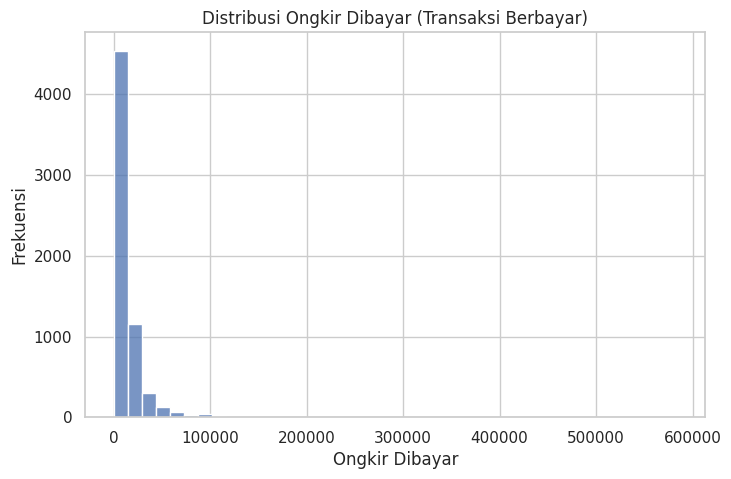

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(df_paid["ongkir_dibayar"], bins=40)
plt.title("Distribusi Ongkir Dibayar (Transaksi Berbayar)")
plt.xlabel("Ongkir Dibayar")
plt.ylabel("Frekuensi")
plt.show()


Distribusi ini menunjukkan variasi biaya logistik yang benar-benar dibayarkan pelanggan.

Beberapa poin yang perlu diperhatikan:
- Apakah distribusi condong ke kanan (right-skewed)?
- Apakah terdapat nilai ekstrem?
- Di rentang berapa mayoritas ongkir berada?

Jika mayoritas ongkir terkonsentrasi pada rentang tertentu, maka struktur biaya relatif stabil.
Sebaliknya, variasi yang sangat lebar dapat mengindikasikan heterogenitas biaya distribusi antar wilayah atau perbedaan struktur tarif.

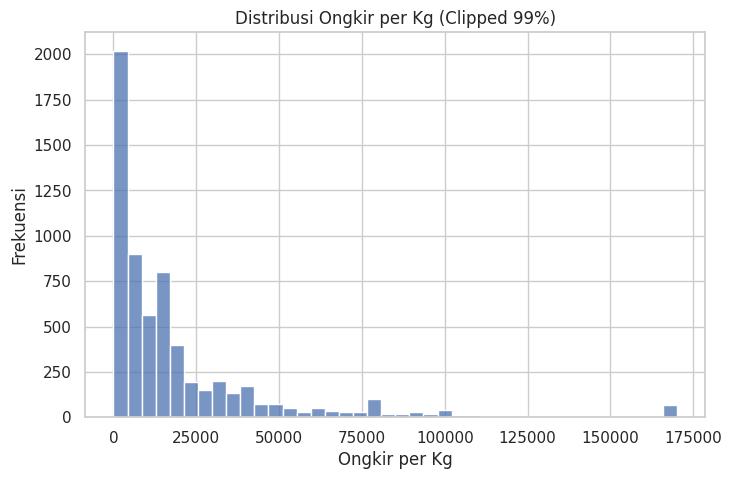

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df_paid["ongkir_per_kg_clipped"], bins=40)
plt.title("Distribusi Ongkir per Kg (Clipped 99%)")
plt.xlabel("Ongkir per Kg")
plt.ylabel("Frekuensi")
plt.show()



In [22]:

df_paid["ongkir_per_kg_clipped"].describe()

,ongkir_per_kg_clipped
count,6296.000000
mean,20114.545645
std,28917.210029
min,0.227273
25%,3137.254902
50%,10000.000000
75%,22500.000000
max,170093.750000


Ongkir per kilogram memberikan gambaran efisiensi biaya relatif terhadap berat barang.
Beberapa interpretasi yang dapat dilakukan:
- Median mencerminkan biaya tipikal per kg
- Selisih antara median dan kuartil atas (75%) menunjukkan variasi biaya
- Jika distribusi sangat lebar, kemungkinan terdapat ketidakefisienan antar wilayah
- Nilai ekstrem telah dibatasi untuk menjaga representativitas visual tanpa menghapus data asl

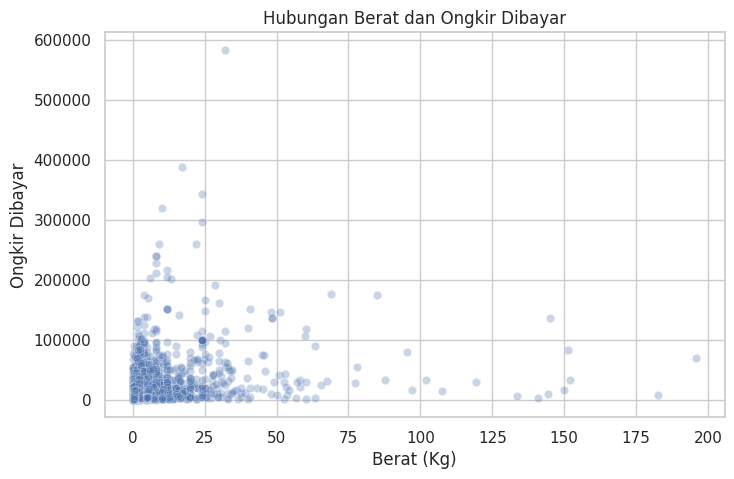

In [23]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x=df_paid["total_berat_kg"],
    y=df_paid["ongkir_dibayar"],
    alpha=0.3
)
plt.title("Hubungan Berat dan Ongkir Dibayar")
plt.xlabel("Berat (Kg)")
plt.ylabel("Ongkir Dibayar")
plt.show()


Secara logis, ongkir seharusnya meningkat seiring bertambahnya berat barang.
Jika pola linear terlihat jelas, maka struktur tarif relatif konsisten.

Namun jika terdapat penyimpangan besar, kemungkinan terdapat:
- Tarif minimum yang dominan
- Ketidaksesuaian estimasi ongkir
- Perbedaan struktur tarif antar wilayah
- Pola berlapis atau bertingkat juga dapat mengindikasikan sistem tarif berbasis pembulatan berat.